# Optimizing Von Mises Stress in Stellarator Coils

End-to-end tutorial from coil DOFs to gradient-based structural optimisation
using **coilforce** + **JAX-FEM**.

## Contents

1. [Setup & imports](#1-setup)
2. [Define base coils (fill in your data)](#2-coils)
3. [Build the CoilFEM container](#3-coilfem)
4. [Diagnostic forward solve & visualisation](#4-run)
5. [Verify gradients with a finite-difference check](#5-grad-check)
6. [JAX-native L-BFGS-B optimisation](#6-jax-optim)
7. [Scipy L-BFGS-B with simsopt objectives](#7-scipy-optim)
8. [Post-processing](#8-postproc)

---
> **Prerequisites**: install coilforce with the `[fem]` extra:  
> `pip install -e '.[fem]'`

The optimisation objective is the **softmax (log-sum-exp smooth max) of Von Mises
stress** summed over all base coils.  Section 7 shows how to add arbitrary
simsopt objectives (quasisymmetry, coil length, …) to the same scipy call.

## 1. Setup & imports <a id='1-setup'></a>

In [1]:
# --- Standard library & numerics ---
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

# --- JAX ---
import jax
import jax.numpy as jnp

# Use 64-bit everywhere; JAX defaults to 32-bit which is too imprecise for FEM.
jax.config.update("jax_enable_x64", True)

# --- coilforce ---
from coilforce.curve_jax   import CurveXYZFourierJAX
from coilforce.coil_fem    import CoilFEM
from coilforce.fem_objectives import (
    soft_max_von_mises,
    mean_von_mises_volume_weighted,
    von_mises_on_quadrature,
)
from coilforce.symmetries  import n_coils_total

# JAX-FEM Landreman-Hurwitz cross-section regularisation helper
from simsopt.field.selffield import regularization_rect

print("JAX devices:", jax.devices())
print("JAX x64 enabled:", jax.config.jax_enable_x64)

# Disable JAX-FEM solver log
import logging
logging.getLogger('jax_fem').setLevel(logging.WARNING)

[06-15 14:41:25][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

JAX devices: [CpuDevice(id=0)]
JAX x64 enabled: True


## 2. Define coils <a id='2-coils'></a>
### 2a. Define Simsopt optimizable

Fill in `base_curves_jax`, `base_currents_jax`, `nfp`, and `stellsym` with your
actual coil configuration.  The rest of the notebook uses only these four
variables.

**Tip**: use `simsopt.configs.get_data('w7x')` (or any other config) and
convert with `CurveXYZFourierJAX.from_simsopt`.

In [2]:
# Loading config from simsopt
from simsopt.configs import get_data
from simsopt.geo import plot
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=20, points_per_period=2)
# list of CurveXYZFourierJAX, one per *base* coil (before symmetry expansion)
base_curves_jax = [CurveXYZFourierJAX.from_simsopt(c) for c in curves[:5]]
base_curves = curves[:5]
# 1-D JAX array of currents [A], shape (n_base,)
base_currents_jax = jnp.array([c.current for c in currents[:5]])
base_currents = currents[:5]
stellsym = True


In [3]:
# ----- quick sanity checks ---------------------------------------------------
n_base = len(base_curves_jax)
n_total = n_coils_total(n_base, nfp, stellsym)
n_quad  = base_curves_jax[0].quadpoints.shape[0]
n_order  = base_curves_jax[0].order
print(f"Base coils : {n_base}")
print(f"Total coils: {n_total}  (nfp={nfp}, stellsym={stellsym})")
print(f"Quad points: {n_quad} per coil")
print(f"Orders: {n_order}")
print(f"DOFs/coil  : {base_curves_jax[0].dofs.shape[0]}")

Base coils : 5
Total coils: 50  (nfp=5, stellsym=True)
Quad points: 40 per coil
Orders: 20
DOFs/coil  : 123


### 2b. Store initial DOFs

We keep the initial values so we can measure how far the optimiser moved and
restart if needed.

In [4]:
# Initial DOF vectors; list of (n_dofs_i,) JAX arrays, one per base coil.
dof_sizes = [int(c.dofs.shape[0]) for c in base_curves_jax]
init_dofs = [c.dofs for c in base_curves_jax]
init_currents = base_currents_jax

print("DOF sizes per coil:", dof_sizes)

DOF sizes per coil: [123, 123, 123, 123, 123]


## 3. Build the CoilFEM container <a id='3-coilfem'></a>
### 3a. Physical/numerical parameters

In [5]:
# Rectangular 100 mm × 50 mm cross-section (half-widths in metres).
# A single dict is broadcast to all base coils automatically.
mesh_options = dict(
    shape        = 'rect',
    w1           = 0.2,   # 0.20 m half-width
    w2           = 0.2,   # 0.20 m half-width
    frame        = 'rmf',
    aspect_ratio = 1.0,   # aim for cubic elements
    mesh_type    = 'TET10',
)

# Winkler BC and linear-solver settings.
problem_options = dict(
    winkler_k      = 1e10,      # Winkler spring stiffness [N/m³]
    solver         = 'umfpack', # A CPU sparse solver. Future version 
    adjoint_solver = 'umfpack', # will support cuSparse GPU sparse solvers.
)

# Material settings
material_options_const_temp = dict(
    E       = 200e9,   # Young's modulus [Pa]
    nu      = 0.30,    # Poisson ratio
    density = 7800.0,  # mass density [kg m⁻³]
)

material_options_variable_temp = dict(
    alpha             = 16.5e-6,  # CTE for 316 LN stainless steel [1/K]
    init_temperature  = 293.15,   # stress-free reference temperature [K]
    final_temperature = 4.0,      # superconducting service temperature [K]
) | material_options_const_temp

### 3b. Support function (`support_fn`)

For auto-diff support, instead of Dirichlet BC, we use a Robin 
(Winkler spring foundation) BC that treats the support points as 
as springs with finite $k$ attached to the boundary. 

The geometry of the support structure is parameterized using a callable
`support_fn(surface_points, coil, dofs) -> weights` that maps

- An array of node positions `surface_points`
- A coil object `coil`
- Some optional optimisable parameters `dofs` (like support structure width and locations)
    
to an array of weights $w_i \in[0, 1]$. This weight will be multipled to the spring coefficient
$k$ to decide whether a node is fully supported (weight=1) or free (weight=0)

`surface_points` is the array of node locations to calculate weights for. 

Use a differentiable weighting (e.g. `jax.nn.sigmoid`) so that `support_dofs`
can enter the gradient-based optimiser.

In [6]:
# Set the size of the support clamp (in other words, the region
# with non-zero Winkler spring coefficients).
# Clamp radius = 2 × coil half-width; sigmoid sharpness tuned to clamp_radius.
clamp_radius = 2 * max(mesh_options['w1'], mesh_options['w2'])
# The "steepness" of the sigmoid function at the edge of the clamp.
sigmoid_beta  = 20.0 / clamp_radius

support_dofs = None   # static support (no optimisable parameters)


def support_fn(
    surface_points: jax.Array,   # (n_surface_nodes, 3)  traced
    coil: 'CurveXYZFourierJAX',  # current coil geometry
    dofs: dict | None,           # optimisable support params (or None)
) -> jax.Array:                  # (n_surface_nodes,) weights in [0, 1]
    """Soft-sphere support at top and bottom of the coil centreline."""
    gamma  = coil.gamma()                              # (n_quad, 3)
    top    = gamma[jnp.argmax(gamma[:, 2])]            # (3,) highest point
    bottom = gamma[jnp.argmin(gamma[:, 2])]            # (3,) lowest point

    # Safe norm: jnp.linalg.norm gradient is NaN at zero distance;
    # adding eps inside sqrt keeps the backward pass finite.
    d_top    = jnp.sqrt(jnp.sum((surface_points - top)**2,    axis=-1) + 1e-10)
    d_bottom = jnp.sqrt(jnp.sum((surface_points - bottom)**2, axis=-1) + 1e-10)

    # sigmoid(beta*(R-d)): ~1 inside sphere of radius clamp_radius, ~0 outside
    w_top    = jax.nn.sigmoid(sigmoid_beta * (clamp_radius - d_top))
    w_bottom = jax.nn.sigmoid(sigmoid_beta * (clamp_radius - d_bottom))
    return jnp.maximum(w_top, w_bottom)   # union of the two spheres


### 3e. Assemble Coil FEM problem container (`CoilFEM`)
`CoilFEM` is a container for the JAXFEM problem. It calculates
the Von Mises stress and performs adjoint differentiation.

In [7]:
fem = CoilFEM(
    base_curves_jax     = base_curves_jax,
    base_currents_jax   = base_currents_jax,
    nfp              = nfp,
    stellsym         = stellsym,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    base_support_fns = support_fn,
    base_support_dofs = support_dofs,
    problem_options  = problem_options,
)

print("CoilFEM built successfully.")
for i, meta in enumerate(fem._grid_meta):
    print(
        f"  coil {i}: {meta['n_cells']} cells, "
        f"{meta['n_quads']} quads/cell, "
        f"shape={meta['shape']}"
    )

/home/lf2869/Documents/Codes/coilforce/src/coilforce/coil_fem.py:679: UserWarning: winkler_exterior: boundary_inds_list[0] had 3840 face entries but face-topology detection found 960 exterior faces. Replacing with topologically correct exterior faces.
  prob = _ProbCls(


CoilFEM built successfully.
  coil 0: 960 cells, 4 quads/cell, shape=rect
  coil 1: 960 cells, 4 quads/cell, shape=rect
  coil 2: 960 cells, 4 quads/cell, shape=rect
  coil 3: 960 cells, 4 quads/cell, shape=rect
  coil 4: 960 cells, 4 quads/cell, shape=rect


### 3f. Visualise Winkler support weights

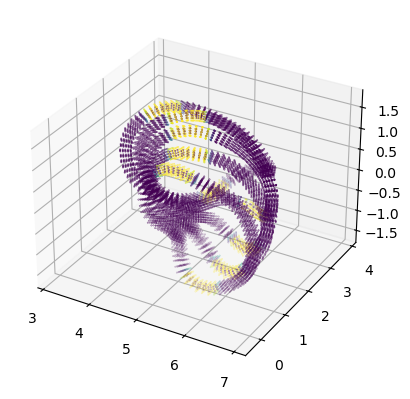

In [8]:
self = fem
import numpy as onp
from coilforce.coil_fem    import _validate_support_dofs

base_curves_dofs = init_dofs

winkler_k = float(self.problem_options['winkler_k'])
sd = _validate_support_dofs(support_dofs, n_base)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
for i, coil_mesh in enumerate(self.meshes):
    pts_i  = self._mesh_points_from_dofs(base_curves_dofs[i], i)
    pts_np = onp.asarray(pts_i, dtype=onp.float64)
    n_nodes = pts_np.shape[0]
    surf_idx = onp.asarray(self._surface_node_indices[i], dtype=onp.int32)
    weights_surf = onp.asarray(
        self._compute_support_weights(i, pts_i, base_curves_dofs[i], sd[i]),
        dtype=onp.float64,
    )
    weight_full = onp.zeros(n_nodes, dtype=onp.float64)
    weight_full[surf_idx] = weights_surf
    ax.scatter(
        pts_np[:, 0], 
        pts_np[:, 1], 
        pts_np[:, 2],
        s=0.1,
        c=weight_full
    )

## 4. Diagnostic forward solve <a id='4-run'></a>

`fem.run()` performs the full FEM pipeline and returns raw solution arrays for
inspection.  **Do not use this for gradient computation** — use
`fem.objective()` instead (Section 5).

In [9]:
t0 = time.perf_counter()
fem.save_run_vtu("test_run", prefix="coil_")
dt = time.perf_counter() - t0
print(f"Forward solve finished in {dt:.1f} s")

Forward solve finished in 8.5 s


## 5. Verify gradients with a finite-difference check <a id='5-grad-check'></a>

Before running optimisation it is good practice to confirm that `jax.grad`
matches a finite-difference estimate on a few DOFs.

In [10]:
# Objective: softmax Von Mises over all base coils.
# fem.objective() returns a dict {metric_name: scalar}; callers combine entries.
# beta controls sharpness; beta→∞ recovers the true max.
BETA = 3000.0    # smoothness; tune to problem scale

def J(base_curves_dofs, base_currents_dofs, support_dofs=None):
    """Scalar softmax Von Mises objective, summed over all base coils."""
    objs = fem.objective(
        base_curves_dofs,
        base_currents_dofs,
        support_dofs,
        metrics = ('soft_max_von_mises',),
    )
    return objs['soft_max_von_mises']

In [11]:
# Test for gradient calculation that overflows a 4060
# Gradient w.r.t. (base_curves_dofs, base_currents_dofs) simultaneously.
# Add argnums=2 if support_dofs are being optimised.
grad_J = jax.grad(J, argnums=(0, 1))

# --- evaluate once to JIT-compile ---
g_dofs, g_curr = grad_J(init_dofs, init_currents)
print("Gradient computed. Shapes:")
for i, gd in enumerate(g_dofs):
    print(f"  coil {i} DOF grad shape: {gd.shape}")
print(f"  current grad shape: {g_curr.shape}")
# ---- Finite-difference check on one DOF of coil 0 ----
h = 1e-5    # step size
dof_idx = 3  # which DOF to perturb

def J_coil0_dof(eps):
    perturbed = init_dofs[0].at[dof_idx].add(eps)
    dofs_p = [perturbed] + init_dofs[1:]
    return J(dofs_p, init_currents)   # support_dofs=None (static)

J_fwd = float(J_coil0_dof(+h))
J_bwd = float(J_coil0_dof(-h))
fd_grad = (J_fwd - J_bwd) / (2 * h)
ad_grad = float(g_dofs[0][dof_idx])

print(f"J: {J_fwd:.6e}")
print(f"FD  gradient: {fd_grad:.6e}")
print(f"AD  gradient: {ad_grad:.6e}")
print(f"Relative err: {abs(fd_grad - ad_grad) / (abs(ad_grad) + 1e-30):.2e}")

Gradient computed. Shapes:
  coil 0 DOF grad shape: (123,)
  coil 1 DOF grad shape: (123,)
  coil 2 DOF grad shape: (123,)
  coil 3 DOF grad shape: (123,)
  coil 4 DOF grad shape: (123,)
  current grad shape: (5,)
J: 6.086592e+09
FD  gradient: -2.183542e+09
AD  gradient: -2.183542e+09
Relative err: 2.71e-08


## 7. Scipy L-BFGS-B with simsopt objectives <a id='7-scipy-optim'></a>

Using `scipy.optimize.minimize` with `jac=True` lets you:

* Mix JAX-computed FEM gradients with simsopt's Python/C++ gradients
  (e.g. quasisymmetry residual, coil length, coil-coil distance).
* Use scipy's richer convergence callbacks and bound handling.
* Plug in other simsopt `LeastSquaresProblem` objectives without rewriting them.

The pattern is:

```
x_flat  →  unpack  →  dofs_list, currents
                           │
              ┌────────────┴──────────────┐
              ▼                           ▼
     JAX FEM objective          simsopt objective
     (jax.value_and_grad)       (update simsopt curves → Jf.J(), Jf.dJ())
              │                           │
              └────────────┬──────────────┘
                           ▼
                  val_total, grad_total  →  (float, np.ndarray)
```

In [12]:
from scipy.optimize import minimize
from simsopt.objectives import SquaredFlux
from simsopt.objectives.utilities import QuadraticPenalty
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
)
from simsopt.field.force import LpCurveForce
from simsopt.field.coil import RegularizedCoil
from simsopt.field.selffield import regularization_rect
from simsopt import load, save
from simsopt.mhd import Vmec
from simsopt.mhd.virtual_casing import VirtualCasing
from simsopt.geo import (
    plot, CurveXYZFourier,
    CurveLength, CurveCurveDistance,
    SurfaceRZFourier,
    CurveSurfaceDistance,
    LinkingNumber,
    create_equally_spaced_curves,
    curves_to_vtk,
    LpCurveCurvature
)
from coilforce.simsopt_bridge    import CoilFEMObjective
from coilforce.support           import CoilSupport

In [13]:
# ---- Virtual casing resolution ----
n_phi = 25        # half fp like in virtual casing convention
n_theta = 50
vc_src_nphi = 40  # half fp like in virtual casing convention
vc_src_ntheta = 80

def load_eq(file_name):
    eq = Vmec(file_name, keep_all_files=True)
    vc = VirtualCasing.from_vmec(
        file_name,
        src_nphi=vc_src_nphi,
        src_ntheta=vc_src_ntheta,
        trgt_nphi=n_phi,
        trgt_ntheta=n_theta,
    )
    Bnormal_plasma = vc.B_external_normal
    plasma_surface_vc = type(eq.boundary)(
        nfp=eq.boundary.nfp,
        stellsym=eq.boundary.stellsym,
        mpol=eq.boundary.mpol, ntor=eq.boundary.ntor,
        quadpoints_phi=np.linspace(0, 1/2/eq.boundary.nfp, n_phi, endpoint=False),
        quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
    )
    plasma_surface_vc.set_dofs(eq.boundary.get_dofs())
    return eq, Bnormal_plasma, plasma_surface_vc, vc


In [14]:
eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')

In [29]:
# Setting targets
Jf_norm = SquaredFlux(
    plasma_surface_vc,
    bs,
    target=Bnormal_plasma,
    definition='normalized',
)
FLUX_NORM_TARGET = Jf_norm.J()

# Coil-coil distance
coils = coils_via_symmetries(base_curves, base_currents, plasma_surface_vc.nfp, True)
curves_for_ccd = [c.curve for c in coils]
Jccdist_init = CurveCurveDistance(curves_for_ccd, 0)
CC_TARGET = Jccdist_init.shortest_distance()

# Coil-surface distance
Jcsdist_init = CurveSurfaceDistance(base_curves, plasma_surface_vc, 0)
CP_TARGET = Jcsdist_init.shortest_distance()

# Curvature 
CURVATURE_TARGET = np.max([c.kappa() for c in base_curves])

# ---- Optimization parameters ----
# To be increased for actual scan
MAXFUN = 1e7
CURVATURE_WEIGHT = 1000
FLUX_WEIGHT = 10000
FORCE_WEIGHT = 5/1e5
LINK_WEIGHT = 10
Lp = 2  # p of Lp curve curvature
CC_WEIGHT = 100
CS_WEIGHT = 100
LENGTH_WEIGHT = 200
FLUX_NORM_TARGET = 5e-4
MAXITER = 5
STRESS_WEIGHT = 1e-10

In [ ]:
# def run_filament_free(base_curves, base_currents_jax, plasma_surface, winding_surface, Bnormal_plasma, MAXITER, force_mode):
force_mode = False
plasma_surface = plasma_surface_vc
coil_per_half_fp = 5
Lp = 2

# --------------------------------------
coils = coils_via_symmetries(base_curves, base_currents, plasma_surface.nfp, True)

curves_for_ccd = [c.curve for c in coils]

bs = BiotSavart(coils)
print('Btarget should have shape', plasma_surface.normal().shape[:2])
print('Btarget has shape', Bnormal_plasma.shape)
bs.set_points(plasma_surface.gamma().reshape((-1, 3)))
Jf_norm = SquaredFlux(
    plasma_surface,
    bs,
    target=Bnormal_plasma,
    definition='normalized',
)
Jf_actual = SquaredFlux(
    plasma_surface,
    bs,
    target=Bnormal_plasma,
    definition='quadratic flux',
)
print('Initial normalized flux', Jf_norm.J())
print('Setting normalized flux target to this value.')
FLUX_NORM_TARGET = Jf_norm.J()
Jf_norm_cons = QuadraticPenalty(Jf_norm, FLUX_NORM_TARGET, 'max')
Jls = [
    QuadraticPenalty(
        CurveLength(c),
        CurveLength(c).J(),
        "max",
    ) for c in base_curves
]
print('Initial lengths', [CurveLength(c).J() for c in base_curves])
print('Setting length targets to these values.')

if force_mode:
    regularized_coils = [RegularizedCoil(
        c.curve, c.current, regularization_rect(0.54, 0.54)
    ) for c in coils]
    Jforce = LpCurveForce(
        target_coils=regularized_coils[:coil_per_half_fp],
        source_coils_coarse=regularized_coils,
    )
    print('Optimizing L2 force')
else:
    # Wrap the static (no-DOF) support_fn in a CoilSupport for CoilFEMObjective.
    class StaticSupport(CoilSupport):
        def __init__(self):
            super().__init__(dofs={})
        @staticmethod
        def support_fn(surface_points, curve_jax, dofs, _fn=support_fn):
            return _fn(surface_points, curve_jax, dofs)

    Jstress = CoilFEMObjective(
        base_curves      = base_curves,
        base_currents    = base_currents,
        base_supports    = [StaticSupport() for _ in base_curves],
        metrics          = ('soft_max_von_mises',),
        metric_weights   = (1.,),
        nfp              = nfp,
        stellsym         = stellsym,
        mesh_options     = mesh_options,
        material_options = material_options_const_temp,
        problem_options  = problem_options,
    )
    print('Optimizing max Von Mises')
Jccdist_actual = CurveCurveDistance(curves_for_ccd, CC_TARGET)
Jccdist = Jccdist_actual * (1 / CC_TARGET)
print('Begin ----------')
plasma_surface_cs = SurfaceRZFourier(
    nfp=plasma_surface.nfp,
    stellsym=plasma_surface.stellsym,
    mpol=plasma_surface.mpol,
    ntor=plasma_surface.ntor,
    quadpoints_phi=np.arange(64)/64,
    quadpoints_theta=np.arange(64)/64,
)
plasma_surface_cs.set_dofs(plasma_surface.get_dofs())
Jcsdist_actual = CurveSurfaceDistance(base_curves, plasma_surface_cs, CP_TARGET)
Jcsdist = Jcsdist_actual * (1 / plasma_surface.minor_radius())
linkNum = LinkingNumber(curves_for_ccd)
Jcs = [
    LpCurveCurvature(
        c, Lp, threshold=CURVATURE_TARGET
    )*(plasma_surface.minor_radius()**Lp) for c in base_curves
]
JF = (
    FLUX_WEIGHT ** 2 * Jf_norm_cons
    + CC_WEIGHT * Jccdist
    + CS_WEIGHT * Jcsdist
    + CURVATURE_WEIGHT * sum(Jcs)
    + LENGTH_WEIGHT * sum(Jls)
    + LINK_WEIGHT * linkNum
)
if force_mode:
    JF = JF + FORCE_WEIGHT * Jforce
else:
    JF = JF + STRESS_WEIGHT * Jstress
    
def fun(dofs):
    JF.x = dofs
    J = JF.J()
    grad = JF.dJ()
    return J, grad

dofs = JF.x

print('MAXITER =', MAXITER)
time_filament_1 = time.time()
res = minimize(
    fun, dofs, jac=True, method='L-BFGS-B',
    options={
        'maxiter': MAXITER,
        'maxcor': 300,
        'maxfun': MAXFUN,
        'maxls': 60,
    },
    tol=1e-10,
)
time_filament_2 = time.time()
filament_time = time_filament_2 - time_filament_1
print('Filament time', filament_time)
print('Normalized flux', Jf_norm.J())
print('L2 force', Jforce.J())
print('Lengths', [j.J() for j in Jls])
print('Max curvatures', [jnp.max(jnp.abs(c.kappa())) for c in base_curves])
print('Final value of terms')
print('    FLUX_WEIGHT**2 * Jf_norm_cons ', FLUX_WEIGHT**2 * Jf_norm_cons.J())
print('    + CC_WEIGHT * Jccdist         ', CC_WEIGHT * Jccdist.J())
print('    + CS_WEIGHT * Jcsdist         ', CS_WEIGHT * Jcsdist.J())
if force_mode:
    print('    + FORCE_WEIGHT * Jforce       ', FORCE_WEIGHT * Jforce.J())
else:
    print('    + STRESS_WEIGHT * Jstress     ', STRESS_WEIGHT * Jstress.J())
print('    + CURVATURE_WEIGHT * sum(Jcs) ', CURVATURE_WEIGHT * sum(Jcs).J())
print('    + LINK_WEIGHT * linkNum       ', LINK_WEIGHT * linkNum.J())
print('    + LENGTH_WEIGHT * sum(Jls)    ', (LENGTH_WEIGHT * sum(Jls)).J())
# return (
#     coils,
#     curves_for_ccd,
#     res,
#     filament_time,
#     Jf_norm,
#     Jf_actual,
#     Jccdist,
#     Jccdist_actual,
#     Jcsdist,
#     Jcsdist_actual,
#     Jforce,
#     Jls,
#     linkNum,
# )

Btarget should have shape (25, 50)
Btarget has shape (25, 50)
Initial normalized flux 5.50473954226856e-07
Setting normalized flux target to this value.
Initial lengths [Array(8.55694, dtype=float64), Array(8.4844, dtype=float64), Array(8.47399, dtype=float64), Array(8.55881, dtype=float64), Array(8.50957, dtype=float64)]
Setting length targets to these values.
Optimizing max Von Mises
Begin ----------
MAXITER = 5


In [ ]:
# Continuation over β: small → large
BETA_SCHEDULE = [5.0, 15.0, 30.0, 60.0]

x_cont = np.asarray(x0)   # warm-start from initial point
 
for beta_val in BETA_SCHEDULE:
    print(f"\n--- β = {beta_val} ---")

    def J_beta(dofs, currents):
        return fem.objective(
            dofs, currents,
            metrics=('soft_max_von_mises',),
        )

    J_and_dJ_beta = jax.jit(jax.value_and_grad(
        lambda x: J_beta(*unpack_x(x))
    ))

    def fun_beta(x_np):
        v, g = J_and_dJ_beta(jnp.asarray(x_np))
        return float(v), np.asarray(g)

    res = scipy.optimize.minimize(
        fun_beta, x_cont,
        method='L-BFGS-B', jac=True,
        bounds=scipy_bounds,
        options=dict(maxiter=50, ftol=1e-10, gtol=1e-6, iprint=-1),
    )
    x_cont = res.x
    print(f"  J = {res.fun:.6e}  converged={res.success}  nit={res.nit}")

dofs_cont, currents_cont = unpack_x(jnp.asarray(x_cont))
print("\nContinuation optimisation complete.")